# Options Analytics — Core Library Demo

This notebook demonstrates the core pricing, Greeks, and implied volatility modules
from the `options_analytics` library.

**Modules covered:**
- `pricing` — Black-Scholes call and put pricing
- `greeks` — Delta, Gamma, Vega, Theta, Rho
- `implied_vol` — Newton-Raphson implied volatility solver

In [1]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from options_analytics.greeks import (
    delta_call,
    delta_put,
    gamma,
    rho_call,
    rho_put,
    theta_call,
    theta_put,
    vega,
)
from options_analytics.implied_vol import ImpliedVolatilityError, implied_volatility
from options_analytics.pricing import black_scholes_call, black_scholes_put
from options_analytics.visualisations import plot_volatility_smile

## Configuration

Standard parameters used throughout as a reference point.

In [2]:
S     = 49.0    # stock price
K     = 50.0    # strike price
R     = 0.05    # risk-free rate
T     = 20/52   # time to expiry in years (~20 weeks)
SIGMA = 0.20    # volatility

---
## 1. Pricing

Black-Scholes prices for a call and put with the reference parameters.

In [3]:
call_price = black_scholes_call(S, K, R, T, SIGMA)
put_price  = black_scholes_put(S, K, R, T, SIGMA)

print(f"Call price : ${call_price:.4f}")
print(f"Put price  : ${put_price:.4f}")

# Put-call parity check: C - P = S - K*exp(-rT)
parity = call_price - put_price - (S - K * np.exp(-R * T))
print(f"\nPut-call parity residual: {parity:.2e}  (should be ~0)")

Call price : $2.4005
Put price  : $2.4482

Put-call parity residual: 0.00e+00  (should be ~0)


### Price vs spot

Call and put prices across a range of spot prices, holding all other parameters fixed.

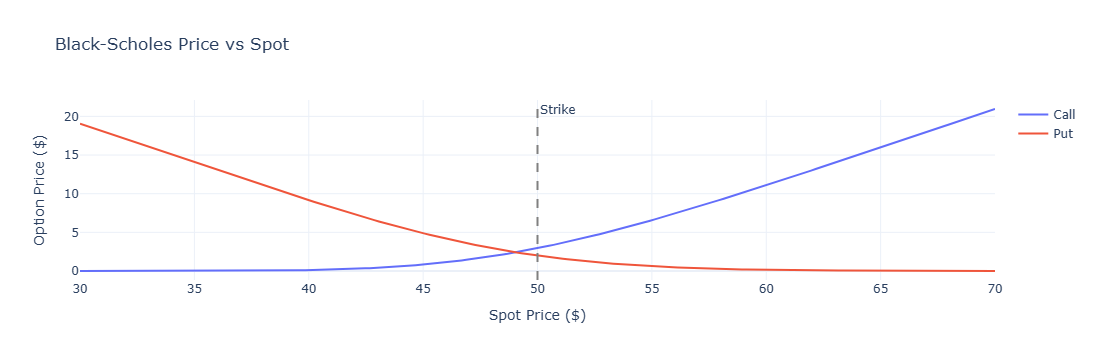

In [4]:
spots = np.linspace(30, 70, 200)
call_prices = [black_scholes_call(s, K, R, T, SIGMA) for s in spots]
put_prices  = [black_scholes_put(s, K, R, T, SIGMA)  for s in spots]

fig = go.Figure()
fig.add_trace(go.Scatter(x=spots, y=call_prices, name="Call", line=dict(color="#636EFA", width=2)))
fig.add_trace(go.Scatter(x=spots, y=put_prices,  name="Put",  line=dict(color="#EF553B", width=2)))
fig.add_vline(x=K, line_dash="dash", line_color="grey", annotation_text="Strike", annotation_position="top right")
fig.update_layout(
    title="Black-Scholes Price vs Spot",
    xaxis_title="Spot Price ($)",
    yaxis_title="Option Price ($)",
    template="plotly_white",
    hovermode="x unified",
)
fig.show()

---
## 2. Greeks

All five Greeks at the reference parameters.

In [5]:
greeks_table = pd.DataFrame([
    {"Greek": "Delta",  "Call": delta_call(S, K, R, T, SIGMA), "Put": delta_put(S, K, R, T, SIGMA)},
    {"Greek": "Gamma",  "Call": gamma(S, K, R, T, SIGMA),      "Put": gamma(S, K, R, T, SIGMA)},
    {"Greek": "Vega",   "Call": vega(S, K, R, T, SIGMA),       "Put": vega(S, K, R, T, SIGMA)},
    {"Greek": "Theta",  "Call": theta_call(S, K, R, T, SIGMA), "Put": theta_put(S, K, R, T, SIGMA)},
    {"Greek": "Rho",    "Call": rho_call(S, K, R, T, SIGMA),   "Put": rho_put(S, K, R, T, SIGMA)},
]).set_index("Greek")

greeks_table.round(4)

,Call,Put
Greek,,
Delta,0.5216,-0.4784
Gamma,0.0655,0.0655
Vega,0.1211,0.1211
Theta,-0.0118,-0.0051
Rho,0.0891,-0.0996


### Greeks vs spot

How each Greek evolves as the spot price moves.

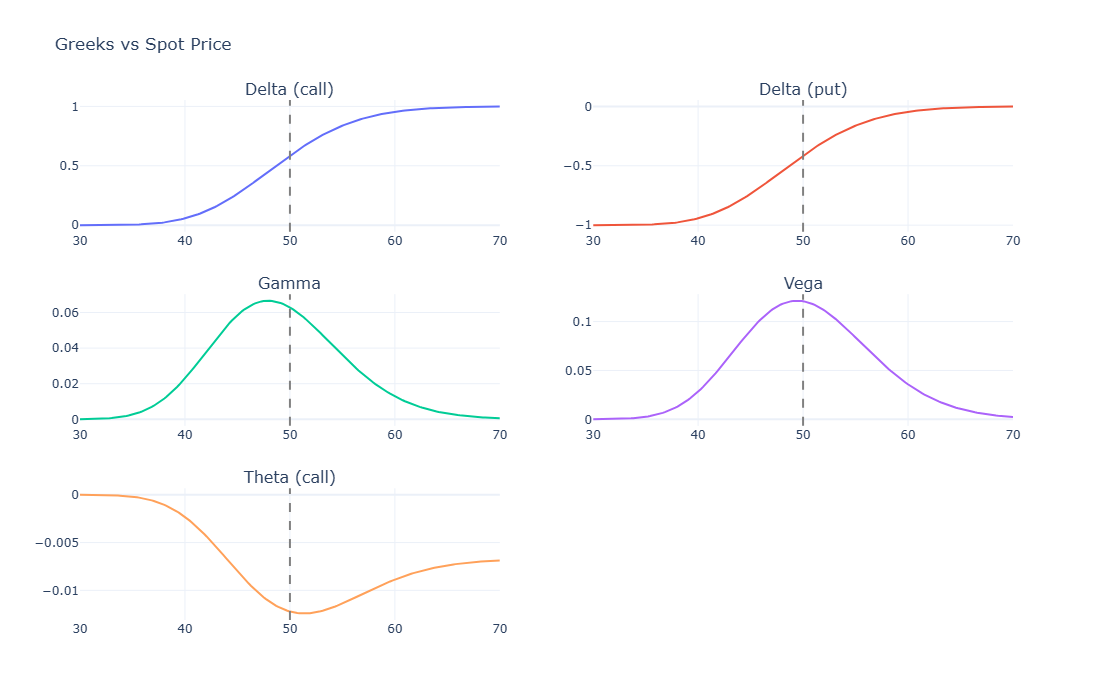

In [6]:
greek_fns = {
    "Delta (call)": lambda s: delta_call(s, K, R, T, SIGMA),
    "Delta (put)":  lambda s: delta_put(s, K, R, T, SIGMA),
    "Gamma":        lambda s: gamma(s, K, R, T, SIGMA),
    "Vega":         lambda s: vega(s, K, R, T, SIGMA),
    "Theta (call)": lambda s: theta_call(s, K, R, T, SIGMA),
}

colours = ["#636EFA", "#EF553B", "#00CC96", "#AB63FA", "#FFA15A"]

fig = make_subplots(
    rows=3, cols=2,
    subplot_titles=list(greek_fns.keys()),
    vertical_spacing=0.12,
    horizontal_spacing=0.1,
)

positions = [(1,1), (1,2), (2,1), (2,2), (3,1)]

for (name, fn), (row, col), colour in zip(greek_fns.items(), positions, colours):
    values = [fn(s) for s in spots]
    fig.add_trace(
        go.Scatter(x=spots, y=values, line=dict(color=colour, width=2), showlegend=False),
        row=row, col=col,
    )
    fig.add_vline(x=K, line_dash="dash", line_color="grey", row=row, col=col)

fig.update_layout(title="Greeks vs Spot Price", height=700, template="plotly_white")
fig.show()

---
## 3. Implied Volatility

The implied volatility solver inverts the Black-Scholes formula to recover the
market-implied volatility from an observed option price.

In [7]:
# Roundtrip: price an option then recover the volatility
true_sigma   = 0.25
market_price = black_scholes_call(S, K, R, T, true_sigma)
solved_sigma = implied_volatility(market_price, S, K, R, T)

print(f"True sigma   : {true_sigma:.6f}")
print(f"Market price : ${market_price:.4f}")
print(f"Solved sigma : {solved_sigma:.6f}")
print(f"Error        : {abs(solved_sigma - true_sigma):.2e}")

True sigma   : 0.250000
Market price : $3.0055
Solved sigma : 0.250000
Error        : 5.18e-08


### Volatility smile

Real equity markets exhibit a volatility skew — implied vol is higher for
low strikes (downside protection demand) than for high strikes. Black-Scholes
assumes a flat smile; the skew below illustrates the real-world deviation.

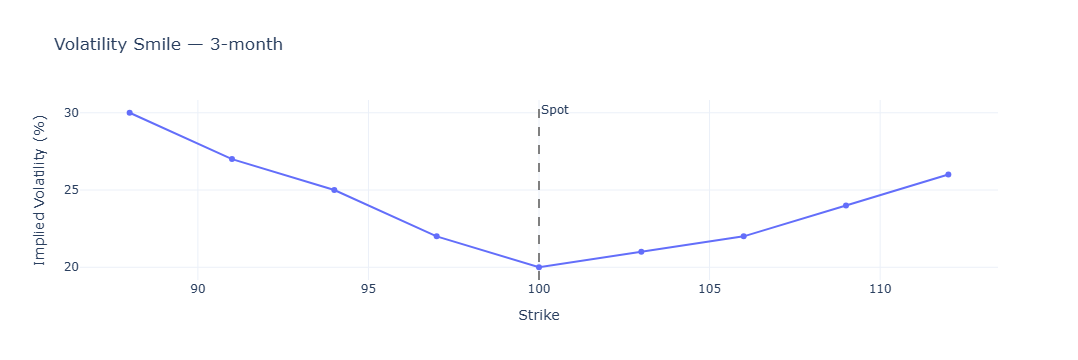

In [9]:
smile_spot    = 100.0
smile_r       = 0.05
smile_t       = 0.25   # 3-month expiry
smile_strikes = [88, 91, 94, 97, 100, 103, 106, 109, 112]

# Equity skew: higher implied vol for lower strikes
true_vols = [0.30, 0.27, 0.25, 0.22, 0.20, 0.21, 0.22, 0.24, 0.26]

prices     = [black_scholes_call(smile_spot, k, smile_r, smile_t, sv)
              for k, sv in zip(smile_strikes, true_vols)]
solved_ivs = [implied_volatility(p, smile_spot, k, smile_r, smile_t)
              for p, k in zip(prices, smile_strikes)]

plot_volatility_smile(
    smile_strikes,
    solved_ivs,
    spot=smile_spot,
    expiry_label="3-month",
).show()

### IV sensitivity to market price

How implied volatility changes as the observed market price increases,
for an ATM option.

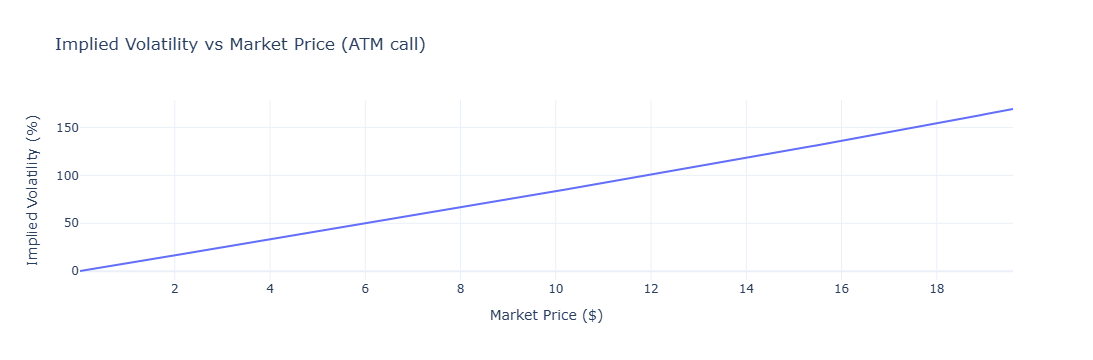

In [10]:
intrinsic  = max(S - K * np.exp(-R * T), 0)
price_grid = np.linspace(intrinsic + 0.01, S * 0.4, 200)
iv_grid    = []

for p in price_grid:
    try:
        iv_grid.append(implied_volatility(p, S, K, R, T) * 100)
    except ImpliedVolatilityError:
        iv_grid.append(None)

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=price_grid,
    y=iv_grid,
    line=dict(color="#636EFA", width=2),
    hovertemplate="Price: $%{x:.2f}<br>IV: %{y:.2f}%<extra></extra>",
))
fig.update_layout(
    title="Implied Volatility vs Market Price (ATM call)",
    xaxis_title="Market Price ($)",
    yaxis_title="Implied Volatility (%)",
    template="plotly_white",
)
fig.show()